## Submitted By:
# Arushi Marwaha 
# CMI MSC DS 1
# Assignment 2

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
train_path = "C:/Users/arush/Desktop/Data/train_dataset"
test_path = "C:/Users/arush/Desktop/Data/test_dataset"

json_path = os.path.join(train_path, "curated_gcp_marks.json")

In [3]:
import os

train_path = "C:/Users/arush/Desktop/Data/train_dataset"

os.listdir(train_path)

['curated_gcp_marks.json', 'Egypt-New Capital City', 'Global Mining Solutions']

In [4]:
import os

os.listdir("C:/Users/arush/Desktop/Data")

['test_dataset', 'train_dataset']

In [5]:
import os

os.listdir("C:/Users/arush/Desktop/Data/train_dataset")

['curated_gcp_marks.json', 'Egypt-New Capital City', 'Global Mining Solutions']

In [6]:
os.listdir("C:/Users/arush/Desktop/Data/train_dataset/Egypt-New Capital City")

['New_Capital_Phase3-Part-1']

In [37]:
import os

os.listdir("C:/Users/arush/Desktop/Data/train_dataset/Egypt-New Capital City/New_Capital_Phase3-Part-1")

['854',
 '855',
 '857',
 '887',
 '895',
 '927',
 '932',
 '936',
 'g207p770',
 'g209p771',
 'g23p809',
 'g250p808',
 'g310p847',
 'T1129',
 'T1131',
 'T1171',
 'T1208',
 'T1210',
 'T1211',
 'T1247',
 'T1249',
 'T1252',
 'T1253',
 'T1328',
 'T1330',
 'T1332',
 'T1371']

In [7]:
import os

base_path = "C:/Users/arush/Desktop/Data"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

C:/Users/arush/Desktop/Data\train_dataset\curated_gcp_marks.json


In [9]:
import json

json_path = "C:/Users/arush/Desktop/Data/train_dataset/curated_gcp_marks.json"

with open(json_path) as f:
    labels = json.load(f)

print("Total labeled images:", len(labels))

Total labeled images: 1000


In [14]:
sample_key = list(labels.keys())[0]
sample_value = labels[sample_key]

print("Image path:", sample_key)
print("Label:", sample_value)

Image path: Kemerton/240222/XLGC1028 230823/DJI_20240222135055_0537.JPG
Label: {'mark': {'x': 2461.370441643842, 'y': 956.8182852908321}, 'verified_shape': 'Cross'}


In [15]:
print(img_path)

C:/Users/arush/Desktop/Data/train_dataset\Kemerton/240222/XLGC1028 230823/DJI_20240222135055_0537.JPG


In [16]:
import os

os.listdir("C:/Users/arush/Desktop/Data/train_dataset")

['curated_gcp_marks.json', 'Egypt-New Capital City', 'Global Mining Solutions']

In [22]:
sample_key

'Kemerton/240222/XLGC1028 230823/DJI_20240222135055_0537.JPG'

In [20]:
import os

print(os.path.exists(img_path))

False


In [21]:
os.listdir(train_path)

['curated_gcp_marks.json', 'Egypt-New Capital City', 'Global Mining Solutions']

In [23]:
import os

valid_keys = []

for key in labels.keys():
    
    img_path = os.path.join(train_path, key)
    
    if os.path.exists(img_path):
        valid_keys.append(key)

print("Total images in JSON:", len(labels))
print("Images actually present:", len(valid_keys))

Total images in JSON: 1000
Images actually present: 189


In [24]:
sample_key = valid_keys[0]
sample_value = labels[sample_key]

print(sample_key)
print(sample_value)

Global Mining Solutions/Survey 1/1/DJI_20241108140600_0055_V.JPG
{'mark': {'x': 2350.080065329657, 'y': 1395.0191285972091}, 'verified_shape': 'Cross'}


In [25]:
img_path = os.path.join(train_path, sample_key)

img = cv2.imread(img_path)

if img is None:
    print("Image not found")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(img.shape)

(3068, 4096, 3)


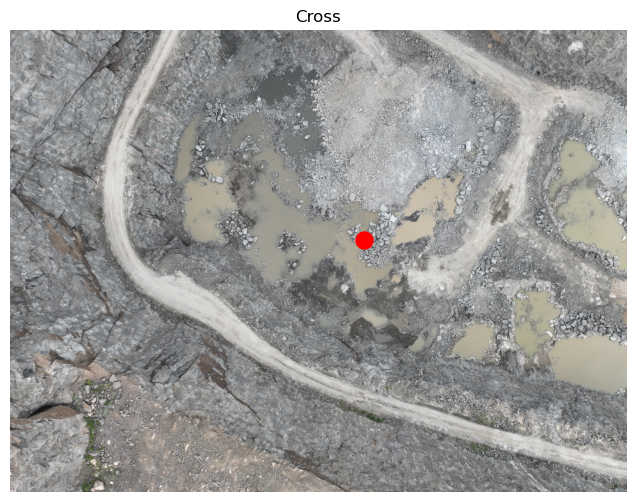

In [26]:
x = sample_value["mark"]["x"]
y = sample_value["mark"]["y"]

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.scatter([x],[y], color="red", s=150)
plt.title(sample_value["verified_shape"])
plt.axis("off")
plt.show()

In [28]:
import os

valid_data = []

for key, value in labels.items():
    
    img_path = os.path.join(train_path, key)
    
    if os.path.exists(img_path):
        valid_data.append((key, value))

print("Total JSON labels:", len(labels))
print("Images available locally:", len(valid_data))

Total JSON labels: 1000
Images available locally: 189


In [29]:
shape_to_id = {
    "Cross":0,
    "Square":1,
    "L-Shaped":2
}

id_to_shape = {v:k for k,v in shape_to_id.items()}

In [30]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np

shape_to_id = {
    "Cross": 0,
    "Square": 1,
    "L-Shaped": 2
}

class GCPDataset(Dataset):

    def __init__(self, data_list, train_path, img_size=256):

        self.data = data_list
        self.train_path = train_path
        self.img_size = img_size

        # ImageNet normalization (important for pretrained ResNet)
        self.mean = np.array([0.485, 0.456, 0.406])
        self.std = np.array([0.229, 0.224, 0.225])


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):

        key, value = self.data[idx]

        img_path = os.path.join(self.train_path, key)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        # Extract coordinates
        x = value["mark"]["x"]
        y = value["mark"]["y"]

        # Normalize coordinates
        x = x / w
        y = y / h

        # Shape label
        shape = shape_to_id[value["verified_shape"]]

        # Resize image
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Normalize pixel values
        img = img / 255.0

        # ImageNet normalization
        img = (img - self.mean) / self.std

        # Convert to tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        coords = torch.tensor([x, y], dtype=torch.float32)
        shape = torch.tensor(shape, dtype=torch.long)

        return img, coords, shape

In [31]:
dataset = GCPDataset(valid_data)

len(dataset)

189

In [36]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [37]:
imgs, coords, shapes = next(iter(loader))

print(imgs.shape)
print(coords.shape)
print(shapes.shape)

torch.Size([8, 3, 512, 512])
torch.Size([8, 2])
torch.Size([8])


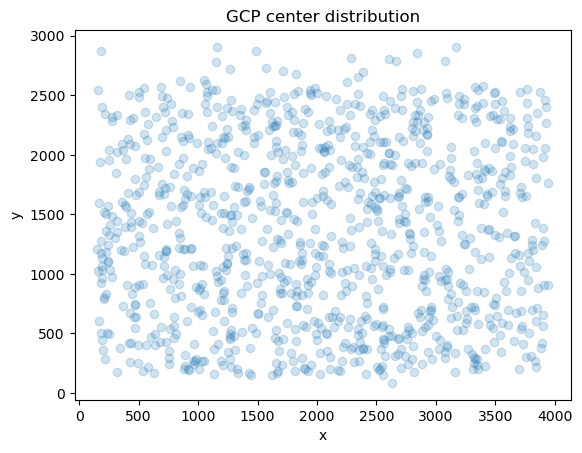

In [32]:
xs = [v["mark"]["x"] for v in labels.values()]
ys = [v["mark"]["y"] for v in labels.values()]

plt.scatter(xs,ys,alpha=0.2)
plt.title("GCP center distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [33]:
test_images = []

for root, dirs, files in os.walk(test_path):
    for file in files:
        if file.endswith(".JPG"):
            test_images.append(os.path.join(root,file))

print("Total test images:", len(test_images))

Total test images: 300


(np.float64(-0.5), np.float64(4095.5), np.float64(2729.5), np.float64(-0.5))

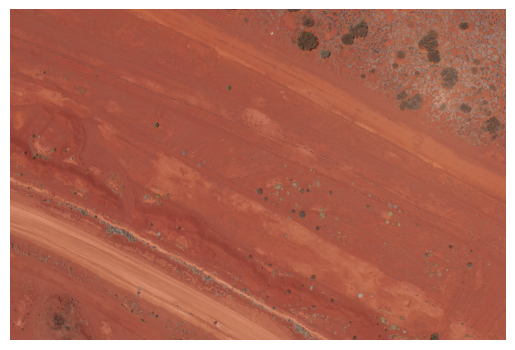

In [34]:
img = cv2.imread(test_images[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [66]:
import torch.nn as nn
import torchvision.models as models


class GCPModel(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = models.resnet18(pretrained=True)

        # Remove final classifier
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        # Coordinate regression head
        self.coord_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

        # Shape classification head
        self.shape_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )


    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        coords = self.coord_head(x)

        shape = self.shape_head(x)

        return coords, shape

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GCPModel().to(device)

C:\Users\arush\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\arush\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\arush/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.68MB/s]


In [40]:
coord_loss = nn.MSELoss()
class_loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [43]:
value["verified_shape"]

'Square'

In [45]:
bad_keys = []

for k, v in labels.items():
    
    if "verified_shape" not in v:
        bad_keys.append(k)

print("Entries missing verified_shape:", len(bad_keys))

Entries missing verified_shape: 3


In [46]:
valid_data = []

for key, value in labels.items():
    
    img_path = os.path.join(train_path, key)
    
    if os.path.exists(img_path):
        
        if "verified_shape" in value and "mark" in value:
            
            if "x" in value["mark"] and "y" in value["mark"]:
                
                valid_data.append((key,value))

print("Total JSON entries:", len(labels))
print("Valid samples used for training:", len(valid_data))

Total JSON entries: 1000
Valid samples used for training: 188


In [50]:
dataset = GCPDataset(valid_data)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [68]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for imgs, coords, shapes in loader:

        imgs = imgs.to(device)
        coords = coords.to(device)
        shapes = shapes.to(device)

        pred_coords, pred_shapes = model(imgs)

        loss1 = coord_loss(pred_coords, coords)
        loss2 = class_loss(pred_shapes, shapes)

        loss = loss1 + loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss/len(loader))

Epoch: 0 Loss: 0.04117887637888392
Epoch: 1 Loss: 0.03740894476262232
Epoch: 2 Loss: 0.037813804189985
Epoch: 3 Loss: 0.038637967935452856


In [51]:
torch.save(model.state_dict(), "gcp_model.pth")

In [53]:
model = GCPModel().to(device)
model.load_state_dict(torch.load("gcp_model.pth", map_location=device))

model.eval()

GCPModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [54]:
id_to_shape = {
    0: "Cross",
    1: "Square",
    2: "L-Shaped"
}

In [55]:
test_path = "C:/Users/arush/Desktop/Data/test_dataset"

test_images = []

for root, dirs, files in os.walk(test_path):
    
    for file in files:
        
        if file.endswith(".JPG") or file.endswith(".jpg"):
            
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, test_path)
            
            test_images.append((full_path, rel_path))

print("Total test images:", len(test_images))

Total test images: 300


In [56]:
import torch

predictions = {}

for full_path, rel_path in test_images:
    
    img = cv2.imread(full_path)
    h, w, _ = img.shape
    
    img_resized = cv2.resize(img, (512,512))
    img_resized = img_resized / 255.0
    
    img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_coords, pred_shape = model(img_tensor)
    
    pred_coords = pred_coords.cpu().numpy()[0]
    
    x = float(pred_coords[0] * w)
    y = float(pred_coords[1] * h)
    
    shape_id = pred_shape.argmax(dim=1).item()
    shape_name = id_to_shape[shape_id]
    
    predictions[rel_path] = {
        "mark": {
            "x": x,
            "y": y
        },
        "verified_shape": shape_name
    }

In [57]:
import json

with open("predictions.json", "w") as f:
    json.dump(predictions, f, indent=4)

print("predictions.json saved")

predictions.json saved


In [58]:
predictions = {}

for full_path, rel_path in test_images:
    
    img = cv2.imread(full_path)
    h, w, _ = img.shape
    
    img_resized = cv2.resize(img, (256,256))
    img_resized = img_resized / 255.0
    
    img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_coords, pred_shape = model(img_tensor)

    pred_coords = pred_coords.cpu().numpy()[0]

    x = float(pred_coords[0] * w)
    y = float(pred_coords[1] * h)

    shape_id = pred_shape.argmax(dim=1).item()
    shape_name = id_to_shape[shape_id]

    predictions[rel_path] = {
        "mark": {
            "x": x,
            "y": y
        },
        "verified_shape": shape_name
    }

In [59]:
import json

with open("predictions.json", "w") as f:
    json.dump(predictions, f, indent=4)

print("predictions.json saved")

predictions.json saved


In [60]:
import os

os.listdir()

['.anaconda',
 '.cache',
 '.cagent',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.docker',
 '.git',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lesshst',
 '.matplotlib',
 '.ssh',
 '.vscode',
 'ADT L2 7thJan .ipynb',
 'ADT PS 1.ipynb',
 'ADT Stack Queues Heap.ipynb',
 'Algorithms.ipynb',
 'anaconda3',
 'AppData',
 'Application Data',
 'Arushi_Marwaha_MDS202512_Assignment 4.ipynb',
 'Arushi_Marwaha_MDS202512_Assignment_5.ipynb',
 'Arushi_Marwaha_MDS202512_Assignment_6.ipynb',
 'Assignment 3 Linkedlist.ipynb',
 'Assignment 3 PDSP.ipynb',
 'Assignment_1pdsp.ipynb',
 'Bank.ipynb',
 'bollywood.ipynb',
 'Class190825.ipynb',
 'Class19aug_Practice_prime.ipynb',
 'Contacts',
 'Cookies',
 'cwd',
 'DCBD-Tutorial',
 'Desktop',
 'Docker Desktop Installer.exe',
 'Documents',
 'Downloads',
 'Dynamic Programming.ipynb',
 'Favorites',
 'FJ.ipynb',
 'gate.ipynb',
 'gcp_model.pth',
 'heap update hlist dict.ipynb',
 'helper_function.py',
 'Links',
 'Local Settings',
 'MDS202

In [61]:
list(predictions.items())[:2]

[('231129_CTD\\231129_CTD_GDA94\\230225gcp11\\DJI_20231129114405_0532.JPG',
  {'mark': {'x': 2647.9619140625, 'y': 1578.103271484375},
   'verified_shape': 'Cross'}),
 ('231129_CTD\\231129_CTD_GDA94\\GCP9\\DJI_20231129125237_0191.JPG',
  {'mark': {'x': 1205.8055419921875, 'y': 3021.900146484375},
   'verified_shape': 'Cross'})]

In [62]:
with open("predictions.json") as f:
    data = json.load(f)

list(data.items())[:3]

[('231129_CTD\\231129_CTD_GDA94\\230225gcp11\\DJI_20231129114405_0532.JPG',
  {'mark': {'x': 2647.9619140625, 'y': 1578.103271484375},
   'verified_shape': 'Cross'}),
 ('231129_CTD\\231129_CTD_GDA94\\GCP9\\DJI_20231129125237_0191.JPG',
  {'mark': {'x': 1205.8055419921875, 'y': 3021.900146484375},
   'verified_shape': 'Cross'}),
 ('Adani GP-III CG\\April_2025\\GCP6\\DJI_20250502114423_0204_D.JPG',
  {'mark': {'x': 1475.22314453125, 'y': 4885.9736328125},
   'verified_shape': 'Cross'})]

In [63]:
len(predictions)

300

In [64]:
for k,v in list(predictions.items())[:5]:
    print(v["mark"])

{'x': 2647.9619140625, 'y': 1578.103271484375}
{'x': 1205.8055419921875, 'y': 3021.900146484375}
{'x': 1475.22314453125, 'y': 4885.9736328125}
{'x': 971.3040161132812, 'y': 2609.15185546875}
{'x': 2967.877197265625, 'y': 1997.097412109375}


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model,(1,3,256,256))